# Лабораторная работа №7
## Декодирование DTMF сигнала

по курсу Цифровая обработка сигналов

**направление**: Речевые технологии и машинное обучение

**преподаватель**: Рыбин Сергей Витальевич

**выполнил**: Юдин Артём Андреевич

**группа**: М4121


In [18]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import itertools as it

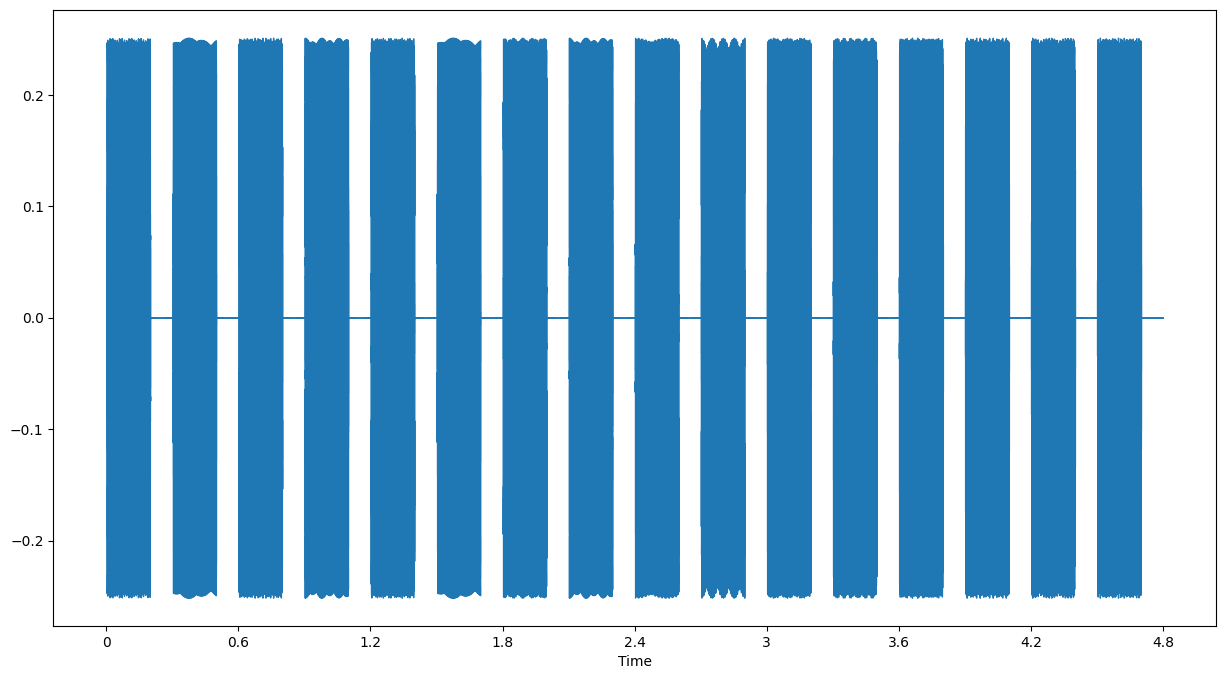

In [19]:
wav, sr = librosa.load("DTMF_Lab13.wav")
plt.figure(figsize=(15, 8))
librosa.display.waveshow(
    wav,
    sr=sr,
)
plt.show()

In [20]:
low_freqs = [697, 770, 852, 941]
high_freqs = [1209, 1336, 1477, 1633]

freq_comb = tuple(it.product(low_freqs, high_freqs))
numbers_letters = (
    "1",
    "2",
    "3",
    "A",
    "4",
    "5",
    "6",
    "B",
    "7",
    "8",
    "9",
    "C",
    "*",
    "0",
    "#",
    "D",
)
dtmf_map = dict(zip(freq_comb, numbers_letters))
dtmf_map

{(697, 1209): '1',
 (697, 1336): '2',
 (697, 1477): '3',
 (697, 1633): 'A',
 (770, 1209): '4',
 (770, 1336): '5',
 (770, 1477): '6',
 (770, 1633): 'B',
 (852, 1209): '7',
 (852, 1336): '8',
 (852, 1477): '9',
 (852, 1633): 'C',
 (941, 1209): '*',
 (941, 1336): '0',
 (941, 1477): '#',
 (941, 1633): 'D'}

In [21]:
def goertzel_power(x: np.ndarray, freq: int, sr: int) -> float:
    N = len(x)
    k = int(round(freq * N / sr))
    alpha = 2 * np.pi * k / N
    coeff = 2 * np.cos(alpha)

    mag = 0
    phi = 0

    for j in range(N - 1, -1, -1):
        g = x[j] + coeff * mag - phi
        phi = mag
        mag = g

    g2 = phi

    power = (mag * np.cos(alpha) - g2) ** 2 + (mag * np.sin(alpha)) ** 2
    return power

In [28]:
# тайминги сигнала - 200 мс сигнал, 100 мс пауза
signal_len = int(0.2 * sr)
pause = int(0.1 * sr)

total_ans = []
i = 0  # начало сигнала
num_signals = 16

for n in range(num_signals):
    start = i
    end = i + signal_len

    frame = wav[start:end]

    low_powers = {f: goertzel_power(frame, f, sr) for f in low_freqs}
    high_powers = {f: goertzel_power(frame, f, sr) for f in high_freqs}

    low = max(low_powers, key=low_powers.get)
    high = max(high_powers, key=high_powers.get)

    ans = dtmf_map[(low, high)]
    total_ans.append(ans)

    i = end + pause

print(f"{num_signals} цифр и букв сигнала №13:\n{', '.join(total_ans)}")

16 цифр и букв сигнала №13:
0, *, 1, #, 2, *, 3, #, 4, A, 5, C, 6, B, 7, D


# Выводы

- Алгоритм Герцеля позволяет эффективно находить сигналы с заданными частотами
- Как и в случае с преобразованием Фурье, частоту сигнала можно определить по его мощности
- В случае неравномерности сигнала можно применить VAD для нахождениев нужных кусков аудио, как это было сделано в перой части курса